In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']
# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


In [2]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
    epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
    validation_data=(x_v, to_categorical(y_v, 10)),
    epochs=epochs, batch_size=batch_size,
    callbacks=cb, verbose=0)

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time:{elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed
def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
      plt.plot(h.history[metric], label=lbl)
      plt.xlabel('Epoch')
      plt.ylabel(ylabel if ylabel else metric)
      plt.title(title)
      plt.legend()
      plt.grid(True)
      plt.show()

In [3]:
from tensorflow import keras
from tensorflow.keras import layers, models

def build_baseline_cnn(optimizer_type, input_shape=(32, 32, 3)):
    # 1. Fixed the typo in the parameter name 'optimizer_type'
    optimizers = {
        'SGD': keras.optimizers.SGD(learning_rate=0.001),
        'Momentum': keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
        'AdaGrad': keras.optimizers.Adagrad(learning_rate=0.001),
        'RMSProp': keras.optimizers.RMSprop(learning_rate=0.001),
        'Adam': keras.optimizers.Adam(learning_rate=0.001),
    }

    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    # 2. Added loss and metrics for a functional compilation
    model.compile(
        optimizer=optimizers[optimizer_type],
        loss='categorical_crossentropy', # Change to 'categorical_crossentropy' if using one-hot
        metrics=['accuracy']
    )

    return model

# Usage Example:
# model = build_baseline_cnn('Adam')

In [4]:
# Exp A: No normalization (raw 0-255)
x_train_a, x_val_a, x_test_a = x_train, x_val, x_test

# Exp B: Min-Max (0-1)
x_train_b, x_val_b, x_test_b = x_train / 255.0, x_val / 255.0, x_test / 255.0

# Exp C: Standardization
mean = np.mean(x_train, axis=(0, 1, 2))
std = np.std(x_train, axis=(0, 1, 2))
x_train_c = (x_train - mean) / std
x_val_c = (x_val - mean) / std
x_test_c = (x_test - mean) / std

experiments = [
    ('None (0-255)', x_train_a, x_val_a, x_test_a),
    ('Min-Max [0,1]', x_train_b, x_val_b, x_test_b),
    ('Standardized', x_train_c, x_val_c, x_test_c)
]

results_1a = []
histories_1a = []

for name, tr_x, val_x, te_x in experiments:
    print(f'\nRunning Experiment: {name}')
    model = build_baseline_cnn('Adam')
    history, test_acc, test_loss, elapsed = train_and_evaluate(model, tr_x, y_train, val_x, y_val, te_x, y_test, epochs=20)
    histories_1a.append(history)
    results_1a.append({
        'Preprocessing': name,
        'Train Acc': history.history['accuracy'][-1],
        'Val Acc': history.history['val_accuracy'][-1],
        'Test Acc': test_acc,
        'Loss @ Epoch 1': history.history['loss'][0]
    })


Running Experiment: None (0-255)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.5759 | Test Loss: 3.0482 | Time:49.0s

Running Experiment: Min-Max [0,1]
Test Acc: 0.6436 | Test Loss: 1.3655 | Time:45.2s

Running Experiment: Standardized
Test Acc: 0.6729 | Test Loss: 2.1635 | Time:45.5s


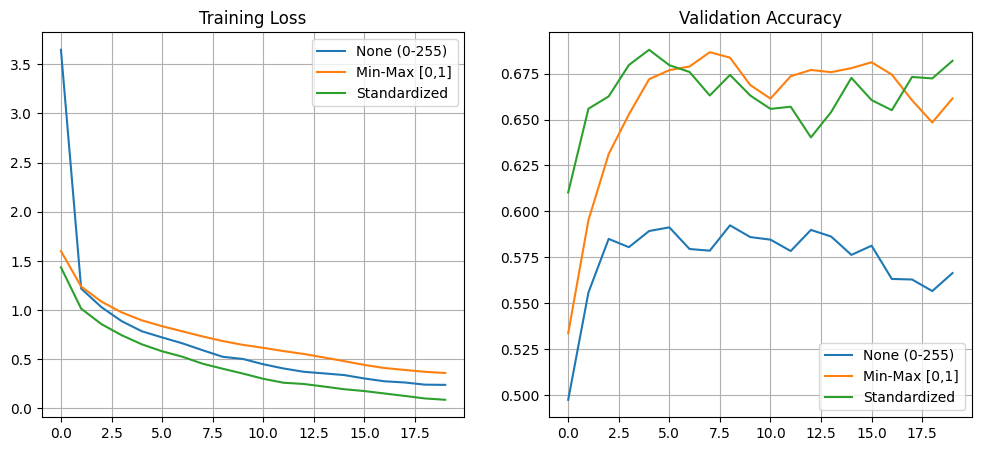

,Preprocessing,Train Acc,Val Acc,Test Acc,Loss @ Epoch 1
0,None (0-255),0.918925,0.5664,0.5759,3.647321
1,"Min-Max [0,1]",0.872625,0.6615,0.6436,1.601012
2,Standardized,0.969850,0.6820,0.6729,1.435235


In [ ]:
labels = [ex[0] for ex in experiments]
# Plot Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for h, L in zip(histories_1a, labels): plt.plot(h.history['loss'], label=L)
plt.title('Training Loss'); plt.legend(); plt.grid(True)
# Plot Val Acc
plt.subplot(1, 2, 2)
for h, L in zip(histories_1a, labels): plt.plot(h.history['val_accuracy'], label=L)
plt.title('Validation Accuracy'); plt.legend(); plt.grid(True)
plt.show()

import pandas as pd
display(pd.DataFrame(results_1a))


Training Baseline (No Augmentation) for 40 epochs...
Test Acc: 0.6753 | Test Loss: 3.2098 | Time:83.0s
Training with Data Augmentation for 40 epochs...


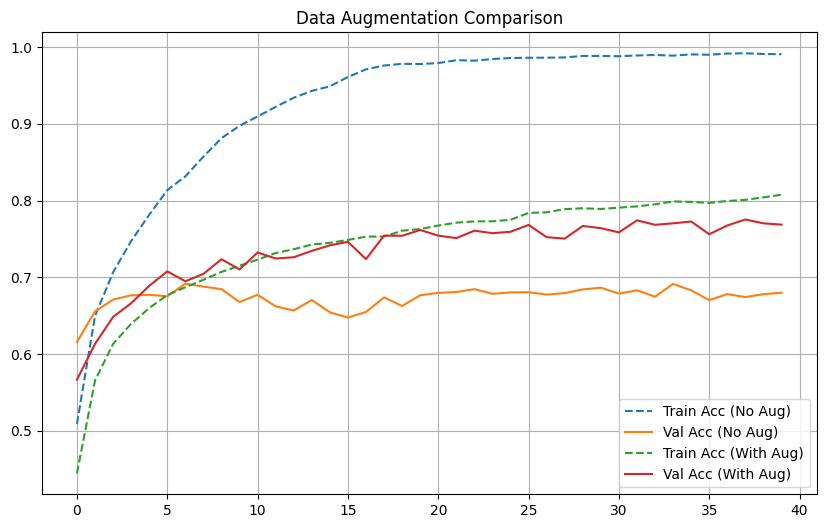

Gap (No Aug): 0.3108
Gap (With Aug): 0.0390


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# 1. No Augmentation (40 epochs)
print('\nTraining Baseline (No Augmentation) for 40 epochs...')
model_no_aug = build_baseline_cnn('Adam')
x_train_aug = x_train_c
x_val_aug = x_val_c
x_test_aug = x_test_c


history_no_aug , test_acc, test_loss, elapsed = train_and_evaluate(model_no_aug, x_train_aug, y_train, x_val_c, y_val, x_test_c, y_test, epochs=40)
# 2. With Augmentation
print('Training with Data Augmentation for 40 epochs...')
datagen = ImageDataGenerator(
    rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, zoom_range=0.1
)
datagen.fit(x_train_aug)

model_aug = build_baseline_cnn('Adam')
history_aug = model_aug.fit(datagen.flow(x_train_aug, to_categorical(y_train, 10), batch_size=128),
                            validation_data=(x_val_c, to_categorical(y_val, 10)),
                            epochs=40, verbose=0)

# Visualization 1B
plt.figure(figsize=(10, 6))
plt.plot(history_no_aug.history['accuracy'], label='Train Acc (No Aug)', linestyle='--')
plt.plot(history_no_aug.history['val_accuracy'], label='Val Acc (No Aug)')
plt.plot(history_aug.history['accuracy'], label='Train Acc (With Aug)', linestyle='--')
plt.plot(history_aug.history['val_accuracy'], label='Val Acc (With Aug)')
plt.title('Data Augmentation Comparison'); plt.legend(); plt.grid(True); plt.show()

gap_no = history_no_aug.history['accuracy'][-1] - history_no_aug.history['val_accuracy'][-1]
gap_aug = history_aug.history['accuracy'][-1] - history_aug.history['val_accuracy'][-1]
print(f'Gap (No Aug): {gap_no:.4f}')
print(f'Gap (With Aug): {gap_aug:.4f}')